## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:


1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?

**Answer**

<blockquote>

Our proposed project pairs two modalities that are fundamentally heterogeneous: crystal graphs (encoding geometry, bond angles, coordination environments as continuous-valued node/edge features) and Robocrystallographer text (encoding symmetry, site descriptions, and bond lengths as discrete token sequences). Without pre-alignment, a cross-modal attention module might receive graph embeddings and text embeddings that are metrically incomparable, and gradient flow through the fusion module could be noisy and slow.

As we primarily focus on numerical property prediction tasks, applying fusion approaches such as nonlinear fusion and gated fusion on the graph and text embeddings from pre-trained unimodal encoders could still preserve enough information from each modality for the task, without any pre-alignment. Such naive approaches should be included for property prediction tasks due to its straightforwardness and time-efficiency. However, some degree of preliminary pre-alignment could still be helpful for the subsequent fusion-prediction procedure, potentially contributing to smoother signal and gradient flows and faster convergence through numerically more comparable and semantically more meaningful embeddings between modalities. Meanwhile, when exploring fusion techniques such as additive fusion, multiplicative fusion, and transformer-based fusion-prediction modules, pre-alignment will be more necessary to create meaningful shared latent space of comparable numerical ranges between graph and text embeddings.

On the other hand, high-level cross-modal alignment will be much more crucial for the potential generation and retrieval tasks in the project, such as proposing material candidate for certain applications / to fullfil certain requirements, or the inverse design of novel structures. Such tasks require strong and reliable semantic connection between the text and graph modalities, necessitating comprehensive pre-alignment before fusing the aligned representations to train a task-specific model agent (e.g. a transformer or graph-comprehending LLM).

</blockquote>

2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?

**Answer**

<blockquote>

**Ablation over fusion depth**

Train different model variants: (a) GNN-only, (b) text-only (SciBERT or MatBERT), (c) nonlinear early fusion (concatenate embeddings before a MLP fusion-prediction module, no pre-alignment), (d) late fusion (concatenate final embeddings before a prediction head, no pre-alignment), (e) cross-modal attention fusion without pre-alignment, (f) cross-modal attention fusion after contrastive pre-alignment (the proposed ALBEF-style model). Compare MAE on numerical property prediction tasks. If the pre-aligned cross-modal attention model (f) outperforms (c-e) even when both use the same unimodal encoders, that isolates the benefit of pre-alignment. Otherwise, fusion without pre-alignment already suffices in the context, and we can compare the performance between (c)(d)(e) to determine the most effective fusion method.


**Challenges foreseen**

The most serious challenge is data sparsity for the text modality. Robocrystallographer generates descriptions algorithmically, but the vocabulary is constrained to a fixed crystallographic ontology. Unlike vision-language datasets with billions of image-caption pairs, the project expects only a few hundreds or thousands perovskite entries, which is far below the data regime where contrastive learning reliably converges. A second challenge is modality imbalance: the GNN has access to precise continuous-valued geometric information (bond lengths to four decimal places), whereas the text discretizes these into categorical phrases ("short Sn–O bonds"). This asymmetry means the text embedding will naturally be noisier, and the momentum distillation mechanism from ALBEF (generating pseudo-targets from a slowly evolving teacher model) may be especially valuable here to prevent the GNN from dominating and the text branch from being ignored during fusion.


</blockquote>

3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?

**Answer**

<blockquote>

The project's two modalities, crystal graphs and Robocrystallographer text, are generated from the same CIF files, making them "bijective projections" of the same underlying reality Z (the crystal structure). The convergence argument in the paper might therefore apply: a GNN trained to predict formation energy and a language model trained on Robocrystallographer text should, in principle, converge to representations where semantically equivalent concepts are assigned similar embeddings.

In the realistic context of this project, automatic convergence might not emerge. Firstly, the paper's convergence guarantees rely on the scaling of both data and model size, but the available data entries are very limited compared to the examples of convergence in the paper. In fact, when considering just $AB0_3$ perovskites, we have at most ~$ 11,000$ different potential compositions, which is unlikely to yield any automatic convergence. Secondly, the text modality in this project is not exactly free-form open natural language (which has a much richer information space), but an algorithmically generated, schema-constrained output of a generator tool, which may compromise the potential of automatic convergence.

However, suppose we extend the database to a much bigger chemical space (say, all known compounds), and suppose we have access to text descriptions in much more flexible forms to capture richer information, then I believe automatic convergence could emerge simply as we scale up for separate unimodal encoders.

</blockquote>

4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.

**Answer**

<blockquote>

(1) Informational Asymmetry between modalities:

 The proof of convergence hypothesis in the paper assumes bijective observation functions, requiring each modality being informationally equivalent to the underlying reality Z. If the different modalities inherently encode different information about the underlying reality, then the assumption no longer holds. In practice, it is common to have different modalities being noisy, lossy, or derived information from the shared underlying reality, which blocks the path to strict convergence.

(2) Low Task Diversity:

 The paper's Multitask Scaling Hypothesis states that alignment increases with the number and diversity of tasks. However, many real-world scenarios are precisely the "special-purpose intelligence" regime that the paper identifies as a counterexample: narrow-task models may find domain-specific shortcuts that diverge from any general Platonic representation. Foe example, a GNN trained only on perovskites may develop representations that encode subtle octahedral tilting patterns with no equivalent in general-purpose materials language models.

(3) Scaling Limitations:

 The paper's empirical evidence shows that alignment between vision and language emerges most clearly for models with hundreds of millions of parameters trained on billions of data points. In most domain-specific scenarios, such as AI for Science fields, it is inherently impossible to have sufficient data size for the platonic representations to emerge.


</blockquote>

5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?

**Answer**

<blockquote>

(1) Alignment-vs-Scale Curve:

Train GNN encoders of increasing capacity (CGCNN with 3, 6, 9 convolutional layers; MEGNet; ALIGNN) and text encoders of increasing capacity (DistilBERT, BERT-base, SciBERT, MatBERT) independently on the perovskite dataset. After training, compute mutual nearest-neighbor alignment scores between all pairs of graph and text encoders on a held-out set. If alignment increases monotonically with encoder capacity (model size), this is positive evidence for emerging convergence.

(2) Cross-Modal Zero-Shot Retrieval:

Given a Robocrystallographer text description for a held-out material, retrieve the top-5 most similar crystal structures by embedding similarity in a shared space (without any explicit cross-modal training). Measure recall and compare to a random baseline and to models explicitly trained with contrastive alignment. If unimodally trained models achieve above-chance retrieval, this supports spontaneous alignment.

(3) Probing for Shared Structure-Property Concepts:

Train linear probes on frozen GNN embeddings and frozen text embeddings separately to predict specific crystallographic attributes (space group number, coordination number of the B-site, average B–O bond length). If both modalities encode these attributes linearly with similar accuracy, this is evidence of shared representational structure emerging even without explicit alignment training.


</blockquote>

6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

**Answer**

<blockquote>

**Potential Downsides of Strong Alignment**

1. Modality collapse. If the contrastive alignment loss is too strong, both encoders are incentivized to project all information into overlapping representation, discarding modality-specific information that has no equivalent in the other modality. For crystal graphs, this could mean discarding fine-grained bond angle information that is unrepresented in Robocrystallographer text. Since bond angles are physically critical for predicting formation energy, over-alignment could hurt regression performance even while improving retrieval metrics.

2. Homogenization of compositionally similar materials. In a low-diversity dataset like $ABO_3$ perovskites, strong alignment might cause the model to collapse structurally similar but physically distinct materials into highly similar embedding vectors, because their text descriptions are nearly identical even though their physical properties differ substantially.

3. Forgetting of graph-specific inductive biases. GNNs for materials benefit from explicit message-passing over bond graphs that encodes geometric invariances (rotation, translation, permutation equivariance). Strong alignment with text embeddings, which lack these invariances, could dilute the geometric inductive bias through backpropagation, degrading generalization to unseen compositions.



**Experiments to Validate**

Train the full model with the ITC contrastive weight $\lambda$ swept over {0, 0.1, 0.5, 1.0, 2.0}. Plot downstream MAE as a function of $\lambda$, and separately plot the alignment score (mutual nearest-neighbor overlap between graph and text embeddings on a held-out set) vs. $\lambda$. If the performance-vs-alignment curve is monotonic and then plateaus, that reveals the minimum alignment needed. If it peaks and then degrades, it indicates over-alignment collapsing modality-specific information

</blockquote>



#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_B.T

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = mat_A @ mat_B

# Element-wise multiplication
mat_mult_elm = mat_A * mat_B.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.3278, 0.4125, 0.2907],
        [0.4946, 0.6633, 0.4209],
        [0.2992, 0.2003, 0.3415]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.einsum('ii->i', A[:2,])

# Outer Product of a and b
outer = torch.einsum('i,j->ij', a.squeeze(1), b.squeeze(1))

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i[0] * j[0] for i, j in zip(to_list(a), to_list(b)))
    assert torch.allclose(ans, torch.tensor(expected))

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(min(len(A_list), len(A_list[0])))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a.squeeze(1)), to_list(b.squeeze(1))
    expected = [[i * j for j in b_l] for i in a_l]
    assert torch.allclose(ans, torch.tensor(expected))

In [ ]:
check_dot_product(d_prod, a, b)
check_transpose(transpose, b)
check_sum_element(sum_element, A)
check_sum_column(sum_column, A)
check_diagonal(diag, A)
check_outer_product(outer, a, b)

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 15.22 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.

In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp

but Gdown can't. Please check connections and permissions.
tar (child): avmnist.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


In [ ]:
import sys
sys.path.append("/content/MultiBench/datasets/avmnist")

from get_data import get_dataloader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/drive/MyDrive/Courses/6.S985/HW2/avmnist/avmnist'

traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel0(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel0, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

In [ ]:
class AudioModel1(nn.Module):
    def __init__(self, dropout_probability=0.3):
        super(AudioModel1, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.Dropout2d(dropout_probability),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AudioModel2(nn.Module):
    def __init__(self, dropout_probability=0.15):
        super(AudioModel2, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 28 -> 28
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7

            nn.Dropout2d(dropout_probability),
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
import torch.nn.functional as F

class ImageModel0(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel0, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

In [ ]:
class ImageModel1(nn.Module):
    def __init__(self, dropout_prob=0.4):
        super(ImageModel1, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(dropout_prob)
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [ ]:
import torch
import torch.nn as nn

class ImageModel2(nn.Module):
    def __init__(self, dropout_prob=0.15):
        super(ImageModel2, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28 -> 28
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_prob)  # moderate dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),  # smaller FC layer
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

# Fix random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# --------------------------
# Model Definition
# --------------------------
class ImageModel3(nn.Module):
    def __init__(self, dropout_prob=0.1):
        super(ImageModel3, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7

            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 7x7
            nn.ReLU(),
            nn.Dropout2d(dropout_prob)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model_0 = AudioModel0()
train_and_test_unimodal(audio_model_0, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1007 | Valid Acc: 37.80%
Epoch 1: Train Loss: 2.0136 | Valid Acc: 39.76%
Epoch 2: Train Loss: 1.9913 | Valid Acc: 40.38%
Epoch 3: Train Loss: 1.9776 | Valid Acc: 40.96%
Epoch 4: Train Loss: 1.9701 | Valid Acc: 41.22%

--- Final Evaluation Complete ---
Final Test Loss: 2.0229 | Test Accuracy: 40.86%


In [ ]:
audio_model = AudioModel1()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1802 | Valid Acc: 34.60%
Epoch 1: Train Loss: 2.0875 | Valid Acc: 34.50%
Epoch 2: Train Loss: 2.0537 | Valid Acc: 38.40%
Epoch 3: Train Loss: 2.0354 | Valid Acc: 38.46%
Epoch 4: Train Loss: 2.0253 | Valid Acc: 39.46%

--- Final Evaluation Complete ---
Final Test Loss: 2.0021 | Test Accuracy: 39.44%


In [ ]:
audio_model = AudioModel2()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1641 | Valid Acc: 37.48%
Epoch 1: Train Loss: 2.0291 | Valid Acc: 39.20%
Epoch 2: Train Loss: 2.0012 | Valid Acc: 40.16%
Epoch 3: Train Loss: 1.9880 | Valid Acc: 40.98%
Epoch 4: Train Loss: 1.9798 | Valid Acc: 41.18%

--- Final Evaluation Complete ---
Final Test Loss: 1.9786 | Test Accuracy: 41.65%


# Image:

In [ ]:
image_model_0 = ImageModel0()
train_and_test_unimodal(image_model_0, traindata, validdata, testdata, modality_idx=0)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 1.1312 | Valid Acc: 66.90%
Epoch 1: Train Loss: 0.9440 | Valid Acc: 68.58%
Epoch 2: Train Loss: 0.9264 | Valid Acc: 68.60%
Epoch 3: Train Loss: 0.9136 | Valid Acc: 68.48%
Epoch 4: Train Loss: 0.9105 | Valid Acc: 69.02%

--- Final Evaluation Complete ---
Final Test Loss: 0.8962 | Test Accuracy: 64.17%


In [ ]:
image_model = ImageModel1()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch 0: Train Loss: 1.0178 | Valid Acc: 67.22%
Epoch 1: Train Loss: 0.9460 | Valid Acc: 67.78%
Epoch 2: Train Loss: 0.9305 | Valid Acc: 66.98%
Epoch 3: Train Loss: 0.9225 | Valid Acc: 68.22%
Epoch 4: Train Loss: 0.9143 | Valid Acc: 68.06%

--- Final Evaluation Complete ---
Final Test Loss: 0.8873 | Test Accuracy: 64.66%


In [ ]:
image_model_2 = ImageModel2()
train_and_test_unimodal(image_model_2, traindata, validdata, testdata, modality_idx=0)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 1.0853 | Valid Acc: 67.70%
Epoch 1: Train Loss: 0.9217 | Valid Acc: 68.02%
Epoch 2: Train Loss: 0.9042 | Valid Acc: 68.66%
Epoch 3: Train Loss: 0.8968 | Valid Acc: 68.02%
Epoch 4: Train Loss: 0.8917 | Valid Acc: 68.58%

--- Final Evaluation Complete ---
Final Test Loss: 0.8971 | Test Accuracy: 63.69%


In [ ]:
image_model_3 = ImageModel3()
train_and_test_unimodal(image_model_3, traindata, validdata, testdata, modality_idx=0)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 1.0855 | Valid Acc: 67.96%
Epoch 1: Train Loss: 0.9160 | Valid Acc: 67.74%
Epoch 2: Train Loss: 0.9000 | Valid Acc: 68.30%
Epoch 3: Train Loss: 0.8932 | Valid Acc: 69.32%
Epoch 4: Train Loss: 0.8904 | Valid Acc: 68.86%

--- Final Evaluation Complete ---
Final Test Loss: 0.8792 | Test Accuracy: 64.67%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.

**Answer**

<blockquote>

### **Audio Model**

The best performance acquired is 41.65%.

The hyperparameters used here are:


**1. Input**
- Shape: `batch_size × 1 × 112 × 112` (grayscale spectrogram)  
- Channels: 1

**2. Convolutional Layers**

| Layer      | In → Out Channels | Kernel | Stride | Padding | Output Size | Activation |
|------------|-----------------|--------|--------|--------|------------|------------|
| Conv1      | 1 → 32          | 3×3    | 2      | 1      | 112 → 56  | ReLU       |
| MaxPool1   | –               | 2×2    | 2      | 0      | 56 → 28   | –          |
| Conv2      | 32 → 64         | 3×3    | 1      | 1      | 28 → 28   | ReLU       |
| MaxPool2   | –               | 2×2    | 2      | 0      | 28 → 14   | –          |
| Conv3      | 64 → 64         | 3×3    | 1      | 1      | 14 → 14   | ReLU       |
| MaxPool3   | –               | 2×2    | 2      | 0      | 14 → 7    | –          |
| Dropout2d  | –               | –      | –      | –      | 7×7×64    | –          |
| Flatten    | –               | –      | –      | –      | 3136       | –          |

**3. Fully Connected Layers**

| Layer | Input Features | Output Features | Activation | Dropout |
|-------|----------------|----------------|-----------|---------|
| FC1   | 3136           | 128            | ReLU      | 0.15    |
| FC2   | 128            | 10             | –         | –       |

**4. Dropout**
- Probability: `0.15`  
- Applied after last conv block (`Dropout2d`) and after first FC layer (`Dropout`)



### **Image Model**

The best performance acquired is 64.67%

The hyperpameters used are:

**1. Input**
- Shape: `batch_size × 1 × 28 × 28` (grayscale image)  
- Channels: 1

**2. Convolutional Layers**

| Layer      | In → Out Channels | Kernel | Stride | Padding | Output Size | Activation |
|------------|-----------------|--------|--------|--------|------------|------------|
| Conv1      | 1 → 32          | 3×3    | 1      | 1      | 28 → 28  | ReLU       |
| MaxPool1   | –               | 2×2    | 2      | 0      | 28 → 14  | –          |
| Conv2      | 32 → 64         | 3×3    | 1      | 1      | 14 → 14  | ReLU       |
| MaxPool2   | –               | 2×2    | 2      | 0      | 14 → 7   | –          |
| Conv3      | 64 → 64         | 3×3    | 1      | 1      | 7 → 7    | ReLU       |
| Dropout2d  | –               | –      | –      | –      | 7×7×64   | –          |
| Flatten    | –               | –      | –      | –      | 3136      | –          |

**3. Fully Connected Layers**

| Layer | Input Features | Output Features | Activation | Dropout |
|-------|----------------|----------------|-----------|---------|
| FC1   | 3136           | 128            | ReLU      | 0.1     |
| FC2   | 128            | 10             | –         | –       |

**4. Dropout**
- Probability: `0.1`  
- Applied after last conv block (`Dropout2d`) and after first FC layer (`Dropout`)

</blockquote>

2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?


**Answer**

<blockquote>

**Performance Comparison & Implications**

- Image modality clearly outperforms audio by ~20–25%.  
- Audio models probably underperform due to:
  - High variability in audio.
  - Less effective feature extraction in current conv architecture.
- Image models perform better because visual digits are easier to classify.

**Suggestions to Improve Audio Models**
- **Data Augmentation:** apply SpecAugment (time/frequency masking), random shifts, noise injection.  
- **Pretraining:** pretrain on larger audio datasets before fine-tuning on AV-MNIST.  
- **Multimodal Fusion:** combine audio and image features for complementary information.

</blockquote>

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(output_dim=64).cuda(), AudioEncoder(output_dim=64).cuda()]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(indim=128, hiddim=256, outdim=10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.8958, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7436, device='cuda:0') acc: 0.727
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7566, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7111, device='cuda:0') acc: 0.7372
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(0.7125, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7451, device='cuda:0') acc: 0.7288


...

Epoch 3 train loss: tensor(0.6780, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7577, device='cuda:0') acc: 0.7244


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6494, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7570, device='cuda:0') acc: 0.7262
Training Time: 261.20551013946533
Training Peak Mem: 9146.6015625
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7099
Inference Time: 3.817211866378784
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?

**Answer**

<blockquote>

If the model training loss is stuck, then it might suggest the model is not learning effectively, possibly due to:
  - Learning rate too high or too low.
  - Poor weight initialization.
  - Model capacity too small or too large.
  - Optimization getting stuck in a local minimum or plateau.
  - Insufficient training data.

Ways to fix this could include:  
 - Adjust learning rate: try reducing or using a learning rate scheduler.  
 - Change optimizer: e.g., switch to Adam/AdamW with proper hyperparameters.  
 - Modify model architecture: add/remove layers, increase/decrease hidden units.  
 - Regularization tuning: adjust dropout, weight decay, or batch normalization.  
 - Data augmentation: increase training variability to improve generalization.  
 - Re-initialize weights: sometimes bad initialization causes training stagnation.  
 - Gradient clipping: prevent exploding gradients


 If the training loss is decreasing, but validation loss is stuck, then the model is probably overfitting the training data, failing to generalize the patterns learnt from training to unseen data.

Ways to fix this could include:
 - Regularization:  Increase dropout probability or add Dropout layers; Use weight decay to penalize large weights.  
 - Data augmentation: Apply transformations to images (rotations, affine transforms) or audio (time/frequency masking, noise).  
 - Reduce model capacity: Fewer conv channels or smaller fully connected layers to prevent memorization.  
 - Early stopping: Stop training once validation metrics stop improving to prevent overfitting.

</blockquote>

2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?

**Answer**

<blockquote>

We are using early fusion (feature-level fusion) with the `Concat()` method. Image and audio features are extracted by separate encoders and **concatenated before the MLP head**.

*Other Fusion Methods:

1. Late fusion (decision-level fusion):  Combine predictions (logits or probabilities) from each modality after separate classification, trough methods such as weighted averaging.  

2. Intermediate / hybrid fusion: Fuse features at multiple points in the network instead of just at the beginning or end.  

3. Multiplicative / bilinear fusion: Captures interactions between modalities more explicitly than simple concatenation.  

4. Gated Fusion & Attention-based fusion: Use attention to weight contributions of each modality depending on context.  

Compared to early fusion, gated or attention-based fusion may improve performance, as audio and image modalities can carry complementary information. Intermediate fusion might also help to increase multimodal interactions that boost final performance.

Due to the two different modalities having unimodal performance gap, late fusion probably won't help to improve. Meanwhile, multiplicative fusion might lose more of the meaningful complimentary information compared to early fusion and will likely not lead to better performane.

</blockquote>

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

**Answer**

<blockquote>



</blockquote>

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

# Unimodal Embeddings

First, acquire unimodal graph and text embeddings from pre-trained models

### Graph Embedding
A pretrained CGCNN for formation energy is used here

**Installation**

In [ ]:
!pip install pymatgen -q
!git clone https://github.com/txie-93/cgcnn.git 2>/dev/null || echo "cgcnn already cloned"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.3 MB/s eta 0:00:00


**Prepare Data**

In [ ]:
import sys, os, json, csv, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Add cloned CGCNN to path
sys.path.insert(0, '/content/cgcnn')
from cgcnn.model import CrystalGraphConvNet
from cgcnn.data import CIFData, collate_pool

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Courses/6.S985/data'

Mounted at /content/drive


In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────

# Pre-trained model to use. Options:
#   'formation-energy-per-atom', 'final-energy-per-atom', 'band-gap',
#   'efermi', 'bulk-moduli', 'shear-moduli', 'poisson-ratio'
PRETRAINED_MODEL = 'band-gap'

MODEL_PATH   = f'/content/cgcnn/pre-trained/{PRETRAINED_MODEL}.pth.tar'
CIF_DIR      = os.path.join(DATA_DIR, 'cif')
MANIFEST_CSV = os.path.join(DATA_DIR, 'manifest.csv')

# Temporary directory laid out the way CIFData expects
CGCNN_DATA_DIR = '/content/cgcnn_input'

# Inference settings
BATCH_SIZE = 64

# Output paths
OUTPUT_NPZ = os.path.join(DATA_DIR, 'graph_embeddings.npz')
OUTPUT_CSV = os.path.join(DATA_DIR, 'graph_embeddings.csv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
os.makedirs(CGCNN_DATA_DIR, exist_ok=True)

# ── Read manifest to get ordered material IDs ────────────────────────────────
manifest = pd.read_csv(MANIFEST_CSV)
material_ids = manifest['material_id'].tolist()
print(f'Materials in manifest: {len(material_ids)}')

# ── Write id_prop.csv (dummy targets — only embeddings matter) ───────────────
id_prop_path = os.path.join(CGCNN_DATA_DIR, 'id_prop.csv')
with open(id_prop_path, 'w', newline='') as f:
    writer = csv.writer(f)
    for mid in material_ids:
        writer.writerow([mid, 0.0])
print(f'Written id_prop.csv ({len(material_ids)} rows)')

# ── Copy atom_init.json from the cloned repo ─────────────────────────────────
atom_init_src = '/content/cgcnn/data/sample-regression/atom_init.json'
atom_init_dst = os.path.join(CGCNN_DATA_DIR, 'atom_init.json')
shutil.copy(atom_init_src, atom_init_dst)
print(f'Copied atom_init.json')

# ── Symlink CIF files into the data directory ─────────────────────────────────
missing, linked = [], 0
for mid in material_ids:
    src = os.path.abspath(os.path.join(CIF_DIR, f'{mid}.cif'))
    dst = os.path.join(CGCNN_DATA_DIR, f'{mid}.cif')
    if not os.path.exists(src):
        missing.append(mid)
        continue
    if not os.path.exists(dst):
        os.symlink(src, dst)
    linked += 1

print(f'Symlinked {linked} CIF files')
if missing:
    print(f'WARNING: {len(missing)} CIF files not found: {missing[:5]}...')

Materials in manifest: 592
Written id_prop.csv (592 rows)
Copied atom_init.json
Symlinked 592 CIF files


**Load Model**

In [ ]:
# ── Load checkpoint ───────────────────────────────────────────────────────────
checkpoint = torch.load(MODEL_PATH, map_location=device)

# Extract model hyperparameters saved with the checkpoint.
# `args` may be a dict or an argparse Namespace depending on the CGCNN version.
raw_args = checkpoint.get('args', {})
args = vars(raw_args) if hasattr(raw_args, '__dict__') else raw_args

atom_fea_len = args.get('atom_fea_len', 64)   # hidden atom feature dim
n_conv       = args.get('n_conv',       3)    # number of graph conv layers
h_fea_len    = args.get('h_fea_len',    128)  # post-pooling hidden dim (= embedding size)
n_h          = args.get('n_h',          1)    # hidden layers after pooling

print(f'Model hyperparameters: atom_fea_len={atom_fea_len}, n_conv={n_conv}, '
      f'h_fea_len={h_fea_len}, n_h={n_h}')

# ── Infer input feature dims from atom_init.json and GaussianDistance defaults ─
with open(atom_init_dst) as f:
    atom_init = json.load(f)
orig_atom_fea_len = len(next(iter(atom_init.values())))  # typically 92

# GaussianDistance(dmin=0, dmax=8, step=0.2) → np.arange(0, 8.2, 0.2) → 41 bins
nbr_fea_len = len(np.arange(0, 8 + 0.2, 0.2))  # 41

print(f'Input dims: orig_atom_fea_len={orig_atom_fea_len}, nbr_fea_len={nbr_fea_len}')

# ── Reconstruct model and load weights ───────────────────────────────────────
model = CrystalGraphConvNet(
    orig_atom_fea_len=orig_atom_fea_len,
    nbr_fea_len=nbr_fea_len,
    atom_fea_len=atom_fea_len,
    n_conv=n_conv,
    h_fea_len=h_fea_len,
    n_h=n_h,
    classification=False,
)
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()
print('Model loaded successfully.')

Model hyperparameters: atom_fea_len=64, n_conv=4, h_fea_len=32, n_h=1
Input dims: orig_atom_fea_len=92, nbr_fea_len=41
Model loaded successfully.


**Embedding Extractor Implementation**

In [ ]:
class CGCNNEmbedder(nn.Module):
    """
    Wraps a pre-trained CrystalGraphConvNet and returns the crystal-level
    embedding (h_fea_len-dim vector) instead of the scalar prediction.

    The embedding is the output of the post-pooling fully-connected stack,
    i.e. everything BEFORE the final fc_out layer.
    """

    def __init__(self, cgcnn_model: CrystalGraphConvNet):
        super().__init__()
        self.m = cgcnn_model

    def forward(self, atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx):
        # 1. Embed raw atom features
        atom_fea = self.m.embedding(atom_fea)           # (N_atoms, atom_fea_len)

        # 2. Graph convolutions
        for conv in self.m.convs:
            atom_fea = conv(atom_fea, nbr_fea, nbr_fea_idx)

        # 3. Mean pooling over atoms → crystal-level feature
        crys_fea = self.m.pooling(atom_fea, crystal_atom_idx)  # (N_crystals, atom_fea_len)

        # 4. Post-pooling FC block
        crys_fea = self.m.conv_to_fc(self.m.conv_to_fc_softplus(crys_fea))  # (N_crystals, h_fea_len)
        crys_fea = self.m.conv_to_fc_softplus(crys_fea)

        # 5. Optional additional hidden layers (only present when n_h > 1)
        if hasattr(self.m, 'fcs') and hasattr(self.m, 'softpluses'):
            for fc, act in zip(self.m.fcs, self.m.softpluses):
                crys_fea = act(fc(crys_fea))

        # Return embedding BEFORE fc_out
        return crys_fea  # (N_crystals, h_fea_len)


embedder = CGCNNEmbedder(model).to(device)
embedder.eval()
print(f'Embedding dim: {h_fea_len}')

Embedding dim: 32


**Get Graph Embeddings**

In [ ]:
# CIFData shuffles internally; we recover order via the returned cif_ids.
dataset = CIFData(CGCNN_DATA_DIR)
loader  = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_pool,
    pin_memory=(device.type == 'cuda'),
)

print(f'Dataset size: {len(dataset)} crystals')
print(f'Batches: {len(loader)} (batch size {BATCH_SIZE})')
print('Running inference...')

all_embeddings = []
all_ids        = []

with torch.no_grad():
    for i, (inputs, _targets, batch_ids) in enumerate(loader):
        atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx = inputs

        atom_fea      = atom_fea.to(device)
        nbr_fea       = nbr_fea.to(device)
        nbr_fea_idx   = nbr_fea_idx.to(device)
        crystal_atom_idx = [idx.to(device) for idx in crystal_atom_idx]

        emb = embedder(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)  # (B, 128)

        all_embeddings.append(emb.cpu().numpy())
        all_ids.extend(batch_ids)

        if (i + 1) % 5 == 0 or (i + 1) == len(loader):
            done = min((i + 1) * BATCH_SIZE, len(dataset))
            print(f'  {done}/{len(dataset)} crystals processed')

embeddings = np.vstack(all_embeddings)   # (N, h_fea_len)
print(f'\nDone. Embeddings shape: {embeddings.shape}')

Dataset size: 592 crystals
Batches: 10 (batch size 64)
Running inference...


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


  320/592 crystals processed


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


  592/592 crystals processed

Done. Embeddings shape: (592, 32)


In [ ]:
# ── Save as compressed NumPy archive ─────────────────────────────────────────
np.savez_compressed(
    OUTPUT_NPZ,
    embeddings=embeddings,
    material_ids=np.array(all_ids),
)
print(f'Saved: {OUTPUT_NPZ}')

# ── Save as CSV merged with manifest ─────────────────────────────────────────
emb_cols = [f'cgcnn_emb_{i}' for i in range(embeddings.shape[1])]
emb_df   = pd.DataFrame(embeddings, columns=emb_cols)
emb_df.insert(0, 'material_id', all_ids)

manifest    = pd.read_csv(MANIFEST_CSV)
result_df   = manifest.merge(emb_df, on='material_id', how='left')
result_df.to_csv(OUTPUT_CSV, index=False)
print(f'Saved: {OUTPUT_CSV}')

# ── Quick sanity check ────────────────────────────────────────────────────────
n_embedded = emb_df['material_id'].nunique()
n_manifest = manifest['material_id'].nunique()
print(f'\nEmbedded {n_embedded}/{n_manifest} materials from manifest')
print(f'Embedding dim: {embeddings.shape[1]}')
print(f'\nSample embedding (first 8 dims of first crystal):')
print(emb_df.iloc[0, 1:9].values)

Saved: /content/drive/MyDrive/Courses/6.S985/data/graph_embeddings.npz
Saved: /content/drive/MyDrive/Courses/6.S985/data/graph_embeddings.csv

Embedded 592/592 materials from manifest
Embedding dim: 32

Sample embedding (first 8 dims of first crystal):
[np.float32(0.00676429) np.float32(2.60253e-40) np.float32(0.0003357588)
 np.float32(5.96721e-19) np.float32(6.3444345e-19)
 np.float32(7.9790246e-12) np.float32(2.430557e-19)
 np.float32(4.27768e-38)]


**More Complex Crystal Graph Embeddings**

In [ ]:
class ComplexCGCNNEmbedder(nn.Module):
    """
    Wraps a pre-trained CrystalGraphConvNet and returns the crystal-level
    embedding (h_fea_len-dim vector) instead of the scalar prediction.

    The embedding is the concatenation of crystal features from each layer:
    - After each graph convolution (pooled)
    - After conv_to_fc
    - After each optional hidden FC layer
    """

    def __init__(self, cgcnn_model: CrystalGraphConvNet):
        super().__init__()
        self.m = cgcnn_model

    def forward(self, atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx):
        layer_embeddings = []

        # 1. Embed raw atom features
        atom_fea = self.m.embedding(atom_fea)           # (N_atoms, atom_fea_len)

        # 2. Graph convolutions — collect crystal feature after each conv layer
        for conv in self.m.convs:
            atom_fea = conv(atom_fea, nbr_fea, nbr_fea_idx)
            crys_fea = self.m.pooling(atom_fea, crystal_atom_idx)  # (N_crystals, atom_fea_len)
            layer_embeddings.append(crys_fea)

        # 3. Post-pooling FC block
        crys_fea = layer_embeddings[-1]  # use last conv output as FC input
        crys_fea = self.m.conv_to_fc(self.m.conv_to_fc_softplus(crys_fea))  # (N_crystals, h_fea_len)
        crys_fea = self.m.conv_to_fc_softplus(crys_fea)
        layer_embeddings.append(crys_fea)

        # 4. Optional additional hidden layers (only present when n_h > 1)
        if hasattr(self.m, 'fcs') and hasattr(self.m, 'softpluses'):
            for fc, act in zip(self.m.fcs, self.m.softpluses):
                crys_fea = act(fc(crys_fea))
                layer_embeddings.append(crys_fea)

        # 5. Concatenate all layer embeddings → final embedding
        final_embedding = torch.cat(layer_embeddings, dim=-1)  # (N_crystals, sum_of_all_dims)
        return final_embedding


embedder = ComplexCGCNNEmbedder(model).to(device)
embedder.eval()

# Calculate total embedding dim: (n_convs * atom_fea_len) + h_fea_len + (n_h * h_fea_len)
n_convs = len(model.convs)
n_h = len(model.fcs) if hasattr(model, 'fcs') else 0
total_embedding_dim = (n_convs * atom_fea_len) + h_fea_len + (n_h * h_fea_len)
print(f'Embedding dim: {total_embedding_dim}')

Embedding dim: 288


In [ ]:
# CIFData shuffles internally; we recover order via the returned cif_ids.
dataset = CIFData(CGCNN_DATA_DIR)
loader  = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_pool,
    pin_memory=(device.type == 'cuda'),
)

print(f'Dataset size: {len(dataset)} crystals')
print(f'Batches: {len(loader)} (batch size {BATCH_SIZE})')
print('Running inference...')

all_embeddings = []
all_ids        = []

with torch.no_grad():
    for i, (inputs, _targets, batch_ids) in enumerate(loader):
        atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx = inputs

        atom_fea      = atom_fea.to(device)
        nbr_fea       = nbr_fea.to(device)
        nbr_fea_idx   = nbr_fea_idx.to(device)
        crystal_atom_idx = [idx.to(device) for idx in crystal_atom_idx]

        emb = embedder(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)  # (B, 128)

        all_embeddings.append(emb.cpu().numpy())
        all_ids.extend(batch_ids)

        if (i + 1) % 5 == 0 or (i + 1) == len(loader):
            done = min((i + 1) * BATCH_SIZE, len(dataset))
            print(f'  {done}/{len(dataset)} crystals processed')

embeddings = np.vstack(all_embeddings)   # (N, h_fea_len)
print(f'\nDone. Embeddings shape: {embeddings.shape}')

Dataset size: 592 crystals
Batches: 10 (batch size 64)
Running inference...


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


  320/592 crystals processed


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


  592/592 crystals processed

Done. Embeddings shape: (592, 288)


In [ ]:
OUTPUT_NPZ = os.path.join(DATA_DIR, 'graph_embeddings_288_band_gap.npz')
OUTPUT_CSV = os.path.join(DATA_DIR, 'graph_embeddings_288_band_gap.csv')

# ── Save as compressed NumPy archive ─────────────────────────────────────────
np.savez_compressed(
    OUTPUT_NPZ,
    embeddings=embeddings,
    material_ids=np.array(all_ids),
)
print(f'Saved: {OUTPUT_NPZ}')

# ── Save as CSV merged with manifest ─────────────────────────────────────────
emb_cols = [f'cgcnn_emb_{i}' for i in range(embeddings.shape[1])]
emb_df   = pd.DataFrame(embeddings, columns=emb_cols)
emb_df.insert(0, 'material_id', all_ids)

manifest    = pd.read_csv(MANIFEST_CSV)
result_df   = manifest.merge(emb_df, on='material_id', how='left')
result_df.to_csv(OUTPUT_CSV, index=False)
print(f'Saved: {OUTPUT_CSV}')

# ── Quick sanity check ────────────────────────────────────────────────────────
n_embedded = emb_df['material_id'].nunique()
n_manifest = manifest['material_id'].nunique()
print(f'\nEmbedded {n_embedded}/{n_manifest} materials from manifest')
print(f'Embedding dim: {embeddings.shape[1]}')
print(f'\nSample embedding (first 8 dims of first crystal):')
print(emb_df.iloc[0, 1:9].values)

Saved: /content/drive/MyDrive/Courses/6.S985/data/graph_embeddings_288_band_gap.npz
Saved: /content/drive/MyDrive/Courses/6.S985/data/graph_embeddings_288_band_gap.csv

Embedded 592/592 materials from manifest
Embedding dim: 288

Sample embedding (first 8 dims of first crystal):
[np.float32(0.1701507) np.float32(0.36620137) np.float32(0.14432137)
 np.float32(0.49494886) np.float32(0.41730744) np.float32(0.5300565)
 np.float32(0.1444724) np.float32(0.14916576)]


### Text Embedding

In [ ]:
!pip install sentence-transformers

In [ ]:
df_text = manifest.loc[manifest['text_ok']].reset_index(drop=True)

texts = []
for f in df_text['text_file']:
    with open(os.path.join(DATA_DIR, f)) as file:
        texts.append(file.read())

print(f'Loaded {len(texts)} text descriptions')

Loaded 493 text descriptions


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load small free model
model = SentenceTransformer('all-MiniLM-L6-v2')

# texts = [...]  # your list of text strings
X_embed = model.encode(texts, show_progress_bar=True)
print("Embedding matrix shape:", X_embed.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding matrix shape: (493, 384)


In [ ]:
import os
import pandas as pd
import numpy as np

# Save as .npz (compressed, efficient for large matrices)
npz_path = os.path.join(DATA_DIR, 'text_embeddings.npz')
np.savez_compressed(npz_path, embeddings=X_embed, filenames=np.array(df_text['text_file'].values))
print(f"Saved embeddings to {npz_path}")

# Save as .csv (human-readable, includes filename index)
csv_path = os.path.join(DATA_DIR, 'text_embeddings.csv')
df_embed = pd.DataFrame(
    X_embed,
    columns=[f'dim_{i}' for i in range(X_embed.shape[1])]
)
df_embed.insert(0, 'text_file', df_text['text_file'].values)
df_embed.to_csv(csv_path, index=False)
print(f"Saved embeddings to {csv_path}")
print(f"CSV shape: {df_embed.shape}")

Saved embeddings to /content/drive/MyDrive/Courses/6.S985/data/text_embeddings.npz
Saved embeddings to /content/drive/MyDrive/Courses/6.S985/data/text_embeddings.csv
CSV shape: (493, 385)


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce embedding dimensions to 32
pca = PCA(n_components=32, random_state=42)
X_embed_pca = pca.fit_transform(X_embed)

explained_variance = pca.explained_variance_ratio_.sum()
print(f"PCA: {X_embed.shape[1]}d → 32d | Explained variance: {explained_variance:.1%}")

# Save as .npz (compressed, efficient for large matrices)
npz_path = os.path.join(DATA_DIR, 'text_pca32_embeddings.npz')
np.savez_compressed(npz_path, embeddings=X_embed_pca, filenames=np.array(df_text['text_file'].values))
print(f"Saved embeddings to {npz_path}")

# Save as .csv (human-readable, includes filename index)
csv_path = os.path.join(DATA_DIR, 'text_pca32_embeddings.csv')
df_embed = pd.DataFrame(
    X_embed_pca,
    columns=[f'dim_{i}' for i in range(X_embed_pca.shape[1])]
)
df_embed.insert(0, 'text_file', df_text['text_file'].values)
df_embed.to_csv(csv_path, index=False)
print(f"Saved embeddings to {csv_path}")
print(f"CSV shape: {df_embed.shape}")

PCA: 384d → 32d | Explained variance: 85.9%
Saved embeddings to /content/drive/MyDrive/Courses/6.S985/data/text_pca32_embeddings.npz
Saved embeddings to /content/drive/MyDrive/Courses/6.S985/data/text_pca32_embeddings.csv
CSV shape: (493, 33)


# Multimodal Fusion

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

**Helper Function for MLP**

In [ ]:
def _make_mlp(in_dim: int, hidden_dims, out_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """
    Build a fully-connected MLP:  Linear -> ReLU -> Dropout (repeated) -> Linear.

    Args:
        in_dim:      input feature size
        hidden_dims: iterable of hidden layer widths (may be empty for a bare linear)
        out_dim:     output feature size
        dropout:     dropout probability applied after every hidden activation
    """
    layers = []
    dims = [in_dim] + list(hidden_dims)
    for i in range(len(dims) - 1):
        layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU(), nn.Dropout(dropout)]
    layers.append(nn.Linear(dims[-1], out_dim))
    return nn.Sequential(*layers)


### Set-up, Prepare Data

In [ ]:
import os
import time
import math
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Courses/6.S985/data'

Mounted at /content/drive


In [ ]:
graph_df = pd.read_csv(os.path.join(DATA_DIR, "graph_embeddings_band_gap.csv"))
text_df  = pd.read_csv(os.path.join(DATA_DIR, "text_pca32_embeddings.csv"))

print("Graph shape:", graph_df.shape)
print("Text shape:", text_df.shape)

Graph shape: (592, 45)
Text shape: (493, 33)


In [ ]:
graph_df.head()

,material_id,formula,a_site,b_site,spacegroup_symbol,split,band_gap,formation_energy_per_atom,energy_above_hull,is_metal,...,cgcnn_emb_22,cgcnn_emb_23,cgcnn_emb_24,cgcnn_emb_25,cgcnn_emb_26,cgcnn_emb_27,cgcnn_emb_28,cgcnn_emb_29,cgcnn_emb_30,cgcnn_emb_31
0,mp-1019544,BaZrO3,Ba,Zr,I4/mcm,train,3.1163,-3.639241,0.000000,False,...,5.311651e-06,1.131451e-22,2.120468e-05,1.673596e-08,5.758210e-05,0.163278,0.291441,2.992205e-18,8.485447e-09,0.489990
1,mp-1079111,EuTiO3,Eu,Ti,I4/mcm,val,0.0000,-3.558522,0.000000,True,...,8.603684e-09,2.131289e-34,5.249537e-08,1.327113e-12,8.584062e-09,0.064177,0.211997,1.290933e-27,4.059281e-13,0.076869
2,mp-1080080,LaAlO3,Al,La,I4/mcm,train,3.5193,-3.722068,0.000399,False,...,1.505386e-06,1.083879e-24,1.145473e-05,3.264737e-09,3.781975e-05,0.152956,0.188573,6.609961e-20,1.365125e-09,0.220792
3,mp-1187247,SrMoO3,Mo,Sr,I4/mcm,train,0.0000,-2.556701,0.040238,True,...,4.216352e-08,1.277863e-31,1.986950e-07,1.336077e-11,1.288069e-07,0.089018,0.084435,2.975281e-25,4.272608e-12,0.418119
4,mp-1206840,SrRhO3,Rh,Sr,I4/mcm,val,0.0000,-1.991144,0.030400,True,...,7.081031e-09,6.889889e-35,4.853287e-08,1.123185e-12,9.520522e-09,0.046644,0.070927,5.355257e-28,3.458861e-13,0.079818


In [ ]:
text_df.head()

,text_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_22,dim_23,dim_24,dim_25,dim_26,dim_27,dim_28,dim_29,dim_30,dim_31
0,text/mp-3731.txt,0.277078,0.283296,0.073693,-0.082176,0.008220,-0.117913,0.030774,0.014681,-0.090745,...,0.075941,0.009596,-0.044612,0.068953,-0.233148,0.024171,-0.028211,0.098459,0.055102,-0.014697
1,text/mp-1078634.txt,0.221144,-0.056754,0.431495,0.094838,0.087885,-0.058970,0.078283,-0.156903,-0.032919,...,0.013116,0.006603,-0.008456,0.047741,-0.009173,0.038260,0.011387,0.040216,0.068059,-0.034093
2,text/mp-19051.txt,0.308838,0.318426,-0.024074,0.106520,0.092783,-0.107225,0.029922,0.023144,-0.025236,...,-0.016450,0.038994,0.025911,0.092212,-0.120587,0.059948,-0.071141,0.033254,0.089875,-0.041818
3,text/mp-3346497.txt,0.096012,0.164648,-0.105116,-0.220526,-0.146957,0.240006,0.116624,-0.060846,-0.105143,...,0.018827,-0.092924,0.008725,-0.004024,0.007920,0.021962,0.027790,0.002954,0.018433,-0.047303
4,text/mp-4531.txt,0.072504,0.171162,-0.113929,-0.226573,-0.140892,0.226904,0.124793,-0.063280,-0.106353,...,0.023312,-0.094110,0.006983,0.003332,0.001162,0.020758,0.023706,0.010455,0.020539,-0.052509


In [ ]:
# Merge on ID
df = graph_df.merge(text_df, on="text_file")

print("Merged shape:", df.shape)

Merged shape: (493, 77)


In [ ]:
# Identify embedding columns
graph_cols = [c for c in df.columns if "cgcnn_emb" in c.lower()]
text_cols  = [c for c in df.columns if "dim_" in c.lower()]

X_graph = df[graph_cols].values
X_text  = df[text_cols].values
y = df["band_gap"].values.reshape(-1, 1)

# Standardize
g_scaler = StandardScaler()
t_scaler = StandardScaler()
y_scaler = StandardScaler()

X_graph = g_scaler.fit_transform(X_graph)
X_text  = t_scaler.fit_transform(X_text)
y       = y_scaler.fit_transform(y)

Xg_train, Xg_test, Xt_train, Xt_test, y_train, y_test = train_test_split(
    X_graph, X_text, y, test_size=0.2, random_state=42
)

In [ ]:
class FusionDataset(Dataset):
    def __init__(self, Xg, Xt, y):
        self.Xg = torch.tensor(Xg, dtype=torch.float32)
        self.Xt = torch.tensor(Xt, dtype=torch.float32)
        self.y  = torch.tensor(y,  dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.Xg[idx], self.Xt[idx], self.y[idx]

In [ ]:
train_ds = FusionDataset(Xg_train, Xt_train, y_train)
test_ds  = FusionDataset(Xg_test, Xt_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

**Helper Functions for Model Analysis**

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_memory_mb(model):
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return param_bytes / 1024**2


def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for g, t, y in loader:
            g, t = g.to(device), t.to(device)
            out = model(g, t)
            preds.append(out.cpu().numpy())
            targets.append(y.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    # Inverse scale
    preds = y_scaler.inverse_transform(preds)
    targets = y_scaler.inverse_transform(targets)

    mae = mean_absolute_error(targets, preds)
    rmse = math.sqrt(mean_squared_error(targets, preds))
    r2 = r2_score(targets, preds)

    return mae, rmse, r2

**Training Loop Function**

In [ ]:
def train_model(model, max_epochs=200, patience=20):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss()

    best_val = float("inf")
    patience_counter = 0
    start_time = time.time()

    for epoch in range(max_epochs):
        model.train()
        for g, t, y in train_loader:
            g, t, y = g.to(device), t.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(g, t)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

        # Validation
        val_mae, _, _ = evaluate(model, test_loader)

        if val_mae < best_val:
            best_val = val_mae
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    convergence_time = time.time() - start_time
    return best_val, convergence_time

# (5 points) Early Fusion

In [ ]:
class EarlyFusion(nn.Module):
    """
    Early Fusion concatenates the raw graph and text embeddings into a single
    joint vector before any learnable transformation, then passes it through a
    shared MLP to produce the prediction.

    Architecture:
        [graph_emb | text_emb]  ->  MLP  ->  pred

    Args:
        graph_dim:   dimensionality of graph embeddings (default 32)
        text_dim:    dimensionality of text embeddings  (default 32)
        hidden_dims: hidden layer widths of the prediction MLP
        out_dim:     output dimension (1 for regression)
        dropout:     dropout probability
    """

    def __init__(
        self,
        graph_dim: int = 32,
        text_dim: int = 32,
        hidden_dims=(128, 64),
        out_dim: int = 1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.mlp = _make_mlp(graph_dim + text_dim, hidden_dims, out_dim, dropout)

    def forward(self, graph_emb: torch.Tensor, text_emb: torch.Tensor) -> torch.Tensor:
        """
        Args:
            graph_emb: [B, graph_dim]
            text_emb:  [B, text_dim]
        Returns:
            predictions: [B, out_dim]
        """
        x = torch.cat([graph_emb, text_emb], dim=-1)   # [B, graph_dim + text_dim]
        return self.mlp(x)                              # [B, out_dim]

In [ ]:
earlyfusion = EarlyFusion()

best_mae, conv_time = train_model(earlyfusion)

mae, rmse, r2 = evaluate(earlyfusion, test_loader)

results_early_fusion = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Params": count_parameters(earlyfusion),
    "MemoryMB": model_memory_mb(earlyfusion),
    "TimeSec": conv_time
}

In [ ]:
results_early_fusion

{'MAE': 0.7453343272209167,
 'RMSE': 1.0696549449249475,
 'R2': 0.6268147230148315,
 'Params': 16641,
 'MemoryMB': 0.06348037719726562,
 'TimeSec': 1.8614835739135742}

In [ ]:
save_dir = "/content/drive/MyDrive/Courses/6.S985/HW2/results"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

pd.DataFrame([results_early_fusion]).to_csv(os.path.join(save_dir, "results_early_fusion.csv"), index=False)

# (5 Points) Late Fusion

In [ ]:
class LateFusion(nn.Module):
    """
    Late Fusion processes each modality through its own independent MLP that
    produces a modality-specific scalar prediction.  The final output is a
    learnable softmax-weighted combination of those predictions.

    Architecture:
        graph_emb  ->  MLP_graph  ->  pred_graph  ─┐
                                                ├─ w·pred_graph + (1-w)·pred_text  ->  pred
        text_emb   ->  MLP_text   ->  pred_text   ─┘

    The fusion weight w is learned via a softmax over a 2-element parameter
    vector so the weights are positive and sum to 1.

    Args:
        graph_dim:   dimensionality of graph embeddings (default 32)
        text_dim:    dimensionality of text embeddings  (default 32)
        hidden_dims: hidden layer widths shared by both modality MLPs
        out_dim:     output dimension (1 for regression)
        dropout:     dropout probability
    """

    def __init__(
        self,
        graph_dim: int = 32,
        text_dim: int = 32,
        hidden_dims=(128, 64),
        out_dim: int = 1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.graph_encoder = _make_mlp(graph_dim, hidden_dims, out_dim, dropout)
        self.text_encoder  = _make_mlp(text_dim,  hidden_dims, out_dim, dropout)
        # Learnable logits → softmax gives convex combination weights
        self.fusion_logits = nn.Parameter(torch.zeros(2))

    def forward(self, graph_emb: torch.Tensor, text_emb: torch.Tensor) -> torch.Tensor:
        """
        Args:
            graph_emb: [B, graph_dim]
            text_emb:  [B, text_dim]
        Returns:
            predictions: [B, out_dim]
        """
        pred_g = self.graph_encoder(graph_emb)      # [B, out_dim]
        pred_t = self.text_encoder(text_emb)        # [B, out_dim]

        w = torch.softmax(self.fusion_logits, dim=0)  # [2], sums to 1
        return w[0] * pred_g + w[1] * pred_t          # [B, out_dim]


In [ ]:
latefusion = LateFusion()

best_mae, conv_time = train_model(latefusion)

mae, rmse, r2 = evaluate(latefusion, test_loader)

results_late_fusion = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Params": count_parameters(latefusion),
    "MemoryMB": model_memory_mb(latefusion),
    "TimeSec": conv_time
}

In [ ]:
results_late_fusion

{'MAE': 0.6820778846740723,
 'RMSE': 0.9752540061886001,
 'R2': 0.6897780299186707,
 'Params': 25092,
 'MemoryMB': 0.0957183837890625,
 'TimeSec': 1.3672370910644531}

In [ ]:
save_dir = "/content/drive/MyDrive/Courses/6.S985/HW2/results"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

pd.DataFrame([results_late_fusion]).to_csv(os.path.join(save_dir, "results_late_fusion.csv"), index=False)

# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):
    """
    Tensor Fusion Network (TFN): each modality is first projected to a lower-
    dimensional space and augmented with a constant 1 (to capture unimodal and
    bias terms).  The outer product of the two augmented vectors is computed via
    torch.einsum, yielding a joint tensor that encodes all pairwise interactions.
    The tensor is then flattened and passed through an MLP.

    Architecture:
        graph_emb  ->  MLP_proj  ->  g  ->  [g | 1]  ─┐
                                                      ├─ outer product  ->  flatten  ->  MLP  ->  pred
        text_emb   ->  MLP_proj  ->  t  ->  [t | 1]  ─┘

    Outer product (einsum):
        fused[b, i, j] = g_hat[b, i] * t_hat[b, j]
        shape: [B, proj_dim+1, proj_dim+1]

    Args:
        graph_dim:   dimensionality of graph embeddings (default 32)
        text_dim:    dimensionality of text embeddings  (default 32)
        proj_dim:    projected modality dimension before outer product
        hidden_dims: hidden layer widths of the prediction MLP
        out_dim:     output dimension (1 for regression)
        dropout:     dropout probability
    """

    def __init__(
        self,
        graph_dim: int = 32,
        text_dim: int = 32,
        proj_dim: int = 16,
        hidden_dims=(128, 64),
        out_dim: int = 1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.graph_proj = _make_mlp(graph_dim, [], proj_dim, dropout)
        self.text_proj  = _make_mlp(text_dim,  [], proj_dim, dropout)

        # After bias augmentation each modality has (proj_dim + 1) dims;
        # the outer product has (proj_dim + 1)^2 elements.
        fused_dim = (proj_dim + 1) ** 2
        self.predictor = _make_mlp(fused_dim, hidden_dims, out_dim, dropout)

    def forward(self, graph_emb: torch.Tensor, text_emb: torch.Tensor) -> torch.Tensor:
        """
        Args:
            graph_emb: [B, graph_dim]
            text_emb:  [B, text_dim]
        Returns:
            predictions: [B, out_dim]
        """
        g = self.graph_proj(graph_emb)  # [B, proj_dim]
        t = self.text_proj(text_emb)    # [B, proj_dim]

        # Augment with a constant 1 to capture unimodal & bias interactions
        ones = torch.ones(g.size(0), 1, device=g.device, dtype=g.dtype)
        g_hat = torch.cat([g, ones], dim=-1)    # [B, proj_dim+1]
        t_hat = torch.cat([t, ones], dim=-1)    # [B, proj_dim+1]

        # Outer product via einsum → [B, proj_dim+1, proj_dim+1]
        # fused[b,i,j] = g_hat[b,i] * t_hat[b,j]
        fused = torch.einsum('bi,bj->bij', g_hat, t_hat)

        # Flatten spatial dims → [B, (proj_dim+1)^2]
        fused = fused.view(fused.size(0), -1)
        return self.predictor(fused)            # [B, out_dim]


In [ ]:
tensorfusion = TensorFusion()

best_mae, conv_time = train_model(tensorfusion)

mae, rmse, r2 = evaluate(tensorfusion, test_loader)

results_tensor_fusion = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Params": count_parameters(tensorfusion),
    "MemoryMB": model_memory_mb(tensorfusion),
    "TimeSec": conv_time
}

In [ ]:
results_tensor_fusion

{'MAE': 0.7706748247146606,
 'RMSE': 1.159283499178782,
 'R2': 0.5616546869277954,
 'Params': 46497,
 'MemoryMB': 0.17737197875976562,
 'TimeSec': 0.9645595550537109}

In [ ]:
save_dir = "/content/drive/MyDrive/Courses/6.S985/HW2/results"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

pd.DataFrame([results_tensor_fusion]).to_csv(os.path.join(save_dir, "results_tensor_fusion.csv"), index=False)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
class LMFFusion(nn.Module):
    """
    Low-Rank Multimodal Fusion (LMF): factorizes the weight tensor of a full
    TFN into a sum of R rank-1 components, one per modality.  This avoids
    explicitly forming the exponentially large fused tensor.

    For M = 2 modalities and rank R, the fusion is:

        z_m[b, r, d]  = Σ_i  W_m[r, d, i] · h_hat_m[b, i]    (einsum)
        fused[b, d]   = Σ_r  z_graph[b, r, d] · z_text[b, r, d]  (einsum)

    which is equivalent to:
        pred = Σ_r (W_graph[r] h_hat_graph) * (W_text[r] h_hat_text)

    where * is element-wise multiplication and W_m[r] ∈ R^{fusion_dim × (proj_dim+1)}.

    Args:
        graph_dim:   dimensionality of graph embeddings (default 32)
        text_dim:    dimensionality of text embeddings  (default 32)
        proj_dim:    projected modality dimension before LMF
        rank:        low-rank approximation rank R
        fusion_dim:  output dimensionality of the LMF operation
        hidden_dims: hidden layer widths of the prediction MLP
        out_dim:     output dimension (1 for regression)
        dropout:     dropout probability
    """

    def __init__(
        self,
        graph_dim: int = 32,
        text_dim: int = 32,
        proj_dim: int = 16,
        rank: int = 4,
        fusion_dim: int = 32,
        hidden_dims=(64,),
        out_dim: int = 1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.graph_proj = _make_mlp(graph_dim, [], proj_dim, dropout)
        self.text_proj  = _make_mlp(text_dim,  [], proj_dim, dropout)

        # Low-rank factor tensors W_m ∈ R^{rank × fusion_dim × (proj_dim+1)}
        # Each W_m[r] ∈ R^{fusion_dim × (proj_dim+1)} is a per-rank projection.
        self.W_graph = nn.Parameter(torch.randn(rank, fusion_dim, proj_dim + 1) * 0.01)
        self.W_text  = nn.Parameter(torch.randn(rank, fusion_dim, proj_dim + 1) * 0.01)

        self.predictor = _make_mlp(fusion_dim, hidden_dims, out_dim, dropout)

    def forward(self, graph_emb: torch.Tensor, text_emb: torch.Tensor) -> torch.Tensor:
        """
        Args:
            graph_emb: [B, graph_dim]
            text_emb:  [B, text_dim]
        Returns:
            predictions: [B, out_dim]
        """
        g = self.graph_proj(graph_emb)  # [B, proj_dim]
        t = self.text_proj(text_emb)    # [B, proj_dim]

        # Augment with bias constant 1 → [B, proj_dim+1]
        ones = torch.ones(g.size(0), 1, device=g.device, dtype=g.dtype)
        g_hat = torch.cat([g, ones], dim=-1)
        t_hat = torch.cat([t, ones], dim=-1)

        # Per-rank, per-output-dim projections
        # W_m[r, d, i] · h_hat[b, i]  →  z_m[b, r, d]
        # einsum: 'rdi, bi -> brd'
        z_g = torch.einsum('rdi,bi->brd', self.W_graph, g_hat)  # [B, rank, fusion_dim]
        z_t = torch.einsum('rdi,bi->brd', self.W_text,  t_hat)  # [B, rank, fusion_dim]

        # Element-wise product across modalities, then sum over rank dimension
        # fused[b, d] = Σ_r  z_g[b, r, d] * z_t[b, r, d]
        # einsum: 'brd, brd -> bd'
        fused = torch.einsum('brd,brd->bd', z_g, z_t)          # [B, fusion_dim]

        return self.predictor(fused)                            # [B, out_dim]


In [ ]:
lmffusion = LMFFusion()

best_mae, conv_time = train_model(lmffusion)

mae, rmse, r2 = evaluate(lmffusion, test_loader)

results_lmf_fusion = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Params": count_parameters(lmffusion),
    "MemoryMB": model_memory_mb(lmffusion),
    "TimeSec": conv_time
}

In [ ]:
results_lmf_fusion

{'MAE': 0.7867252826690674,
 'RMSE': 1.1723975987239625,
 'R2': 0.5516812205314636,
 'Params': 7585,
 'MemoryMB': 0.028934478759765625,
 'TimeSec': 1.5671281814575195}

In [ ]:
save_dir = "/content/drive/MyDrive/Courses/6.S985/HW2/results"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

pd.DataFrame([results_lmf_fusion]).to_csv(os.path.join(save_dir, "results_lmf_fusion.csv"), index=False)

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

In [ ]:
save_dir = "/content/drive/MyDrive/Courses/6.S985/HW2/results"

all_results= []
for method in ["early_fusion", "late_fusion", "tensor_fusion", "lmf_fusion"]:
    results = pd.read_csv(os.path.join(save_dir, f"results_{method}.csv"))
    results.insert(0, "method", method)
    all_results.append(results)

df_results = pd.concat(all_results).reset_index(drop=True)
df_results


,method,MAE,RMSE,R2,Params,MemoryMB,TimeSec
0,early_fusion,0.745334,1.069655,0.626815,16641,0.063480,1.861484
1,late_fusion,0.682078,0.975254,0.689778,25092,0.095718,1.367237
2,tensor_fusion,0.770675,1.159283,0.561655,46497,0.177372,0.964560
3,lmf_fusion,0.786725,1.172398,0.551681,7585,0.028934,1.567128


**Answer**

<blockquote>

### **Performances**

Among the 4 implemented fusion methods, the best validation performance was reported from Late Fusion.

The corresponding best evaluaton metrics are:

 - $\text{MAE} = 0.6821 \text{ eV}$

 - $\text{RMSE} = 0.9752 \text{ eV}$

 - $\text{R}^2 = 0.6898$

### **Hyperparameters**

**Input Dimensions**
- `graph_dim = 32` — size of graph embeddings  
- `text_dim = 32` — size of text embeddings  

**MLP Architecture (per modality)**

Each modality has its own independent MLP:
- `hidden_dims = (128, 64)` — hidden layer sizes  
- `dropout = 0.1` — dropout after each hidden layer  
- `out_dim = 1` — output dimension (1 for regression)  


**Fusion Mechanism**
- `fusion_logits` (learned, shape = [2])  
- Softmax applied to produce convex weights  
- Final prediction:  
  `pred = w_1 · pred_graph + w_2 · pred_text`

**Training Parameters**
- Learning rate `lr=1e-3`
- Optimizer `torch.optim.Adam()`
- `max_epochs = 200` - Training for at most 200 epochs if not early stopping
- `patience = 20`: max count of plateau validation loss before early stopping

### **Which Fusion Method Is Likely Best?**

For this dataset, Late Fusion is most likely to perform best, due to the following reasons:

 - Small Dataset Size: Tensor Fusion (TFN) dramatically increases feature dimensionality via outer products; LMF reduces this but still introduces many interaction parameters.With limited data, high-capacity interaction models risk overfitting.

 - Precomputed Embeddings: Both graph and text embeddings are already compressed, high-level representations. Much cross-modal interaction may already be implicitly encoded, and a weighted combination may be sufficient.

Meanwhile, late fusion provides some interpretability by tuning the contribution of each modality.

Similarly, attention-based fusion like gated fusion may also yield good performances and interpretability. With larger pretrained models and higher unimodal representation dimensionality, attention-based methods may outperform late fusion.

</blockquote>

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

**Parameter Count**

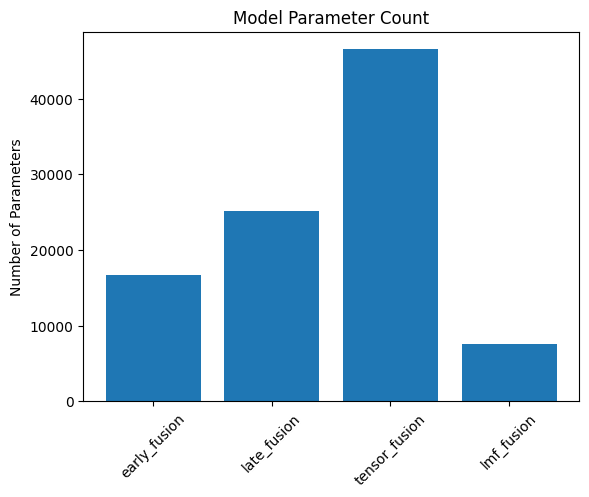

In [ ]:
plt.figure()
plt.bar(df_results["method"], df_results["Params"])
plt.ylabel("Number of Parameters")
plt.title("Model Parameter Count")
plt.xticks(rotation=45)
plt.show()

**Memory Use**

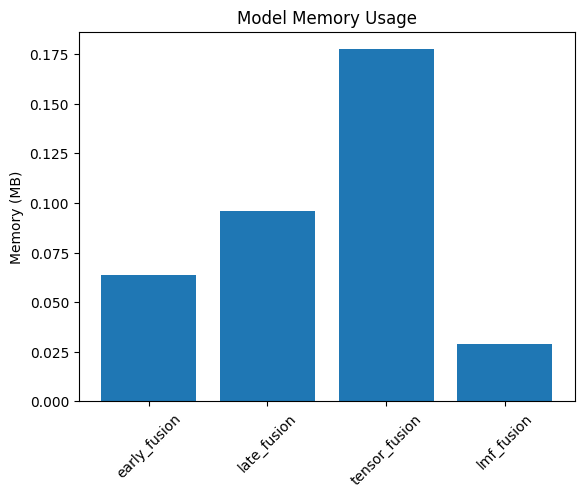

In [ ]:
plt.figure()
plt.bar(df_results["method"], df_results["MemoryMB"])
plt.ylabel("Memory (MB)")
plt.title("Model Memory Usage")
plt.xticks(rotation=45)
plt.show()

**Converngence Time**

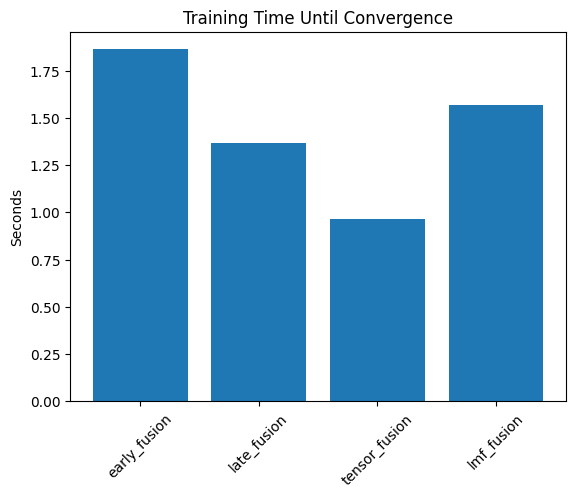

In [ ]:
plt.figure()
plt.bar(df_results["method"], df_results["TimeSec"])
plt.ylabel("Seconds")
plt.title("Training Time Until Convergence")
plt.xticks(rotation=45)
plt.show()

### Unimodal vs Multimodal

**Multimodal Pros**
- Captures complementary information across modalities
- More robust to modality-specific noise

**Multimodal Cons**
- Higher parameter count and memory usage
- Increased architectural and training complexity

### Fusion Method Comparison

**Early Fusion**
- Moderate accuracy and complexity
- Simple concatenation-based approach
- Limited modeling of cross-modal interactions

**Late Fusion (Best Performance)**
- Best performance in the tested case
- Modality-specific feature learning before aggregation
- Good balance of accuracy, efficiency, and robustness

**Tensor Fusion**
- Highest parameter count and memory usage
- Models high-order multiplicative interactions
- Underperforms here, likely due to overfitting

**Low-Rank Multimodal Fusion (LMF)**
- Most parameter-efficient
- Lowest memory footprint
- Underperforms, likely underfitting due to reduced capacity

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-si9064ae
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-si9064ae
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=24dff6dde081a659ad3705ff41f2a22e2dc98db9ed2e961f4a22639ed6cda824
  Stored in directory: /tmp/pip-ephem-wheel-cache-09qxk4xq/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 45.3MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "smiling_person.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 98.44%
       a photo of a sad person: 1.13%
    a photo of an angry person: 0.42%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    super().__init__()

    # 1.
    self.encoder_a = nn.Sequential(
        nn.Linear(dim_x1, dim_x1),
        nn.ReLU(),
        nn.Linear(dim_x1, dim_x1)
    )
    self.encoder_b = nn.Sequential(
        nn.Linear(dim_x2, dim_x2),
        nn.ReLU(),
        nn.Linear(dim_x2, dim_x2)
    )

    # 2.
    self.projector_a = nn.Sequential(
        nn.Linear(dim_x1, embedded_dim),
        nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim)
    )
    self.projector_b = nn.Sequential(
        nn.Linear(dim_x2, embedded_dim),
        nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim)
    )

    # 3.
    self.scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # 1. Extract raw features via encoders
    h1 = self.encoder_a(x1)
    h2 = self.encoder_b(x2)

    # 2. Project to shared embedding space
    z1 = self.projector_a(h1)
    z2 = self.projector_b(h2)

    # 3. L2-normalize embeddings
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)

    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    # TODO: Initialize model and loss function as cross entropy loss
    super().__init__()
    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2

    # 1. Batch size from embedding dimension
    batch_size = x1_emb.shape[0]

    # 2. Similarity matrix scaled by learnable temperature
    #    shape: (batch_size, batch_size)
    scale = self.model.scale.exp()
    sim_matrix = torch.einsum('id,jd->ij', x1_emb, x2_emb) * scale

    # 3. Labels: correct match for index i is index i
    labels = torch.arange(batch_size, device=x1_emb.device)

    # 4. Symmetric loss: rows (x1->x2) + cols (x2->x1), divided by 2
    loss_rows = self.loss_fn(sim_matrix, labels)
    loss_cols = self.loss_fn(sim_matrix.T, labels)
    loss = (loss_rows + loss_cols) / 2

    return loss

In [ ]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            # loss = contrastive_loss(emb_a, emb_b, model.logit_scale)
            loss = contrastive_loss(emb_a, emb_b)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

**Data Preparation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Courses/6.S985/data'

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader

# 1. Load and align CSV files
graph_dim = 288
text_dim = 384

graph_df = pd.read_csv(os.path.join(DATA_DIR, "graph_embeddings_288_band_gap.csv"))
text_df = pd.read_csv(os.path.join(DATA_DIR, "text_embeddings.csv"))

# Merge on identifier
merged_df = pd.merge(graph_df, text_df, on="text_file")

print("Merged shape:", merged_df.shape)

merged_df.to_csv(os.path.join(DATA_DIR, f"merged_embeddings_{graph_dim}_{text_dim}.csv"), index=False)


# 2. Extract embeddings

graph_cols = [c for c in merged_df.columns if "cgcnn_emb" in c.lower()]
text_cols  = [c for c in merged_df.columns if "dim_" in c.lower()]

graph_embeddings = merged_df[graph_cols].values
text_embeddings  = merged_df[text_cols].values

# Convert to float32 tensors
graph_tensor = torch.tensor(graph_embeddings, dtype=torch.float32)
text_tensor  = torch.tensor(text_embeddings, dtype=torch.float32)

print("Graph tensor:", graph_tensor.shape)
print("Text tensor:", text_tensor.shape)

Merged shape: (493, 685)
Graph tensor: torch.Size([493, 288])
Text tensor: torch.Size([493, 384])


In [ ]:
# 3. Create Dataset

class ContrastiveDataset(Dataset):
    def __init__(self, graph_tensor, text_tensor):
        assert graph_tensor.shape[0] == text_tensor.shape[0]
        self.graph = graph_tensor
        self.text = text_tensor

    def __len__(self):
        return self.graph.shape[0]

    def __getitem__(self, idx):
        return self.graph[idx], self.text[idx]


dataset = ContrastiveDataset(graph_tensor, text_tensor)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True
)

print("Dataset size:", len(dataset))

Dataset size: 493


**Training**

In [ ]:
# 4. Initialize model

embedded_dim = 256
temperature = 0.07

model = CLModel(
    dim_x1=288,
    dim_x2=384,
    embedded_dim=embedded_dim,
    temp=temperature
)

contrastive_loss = ContrastiveLoss(model)

# 5. Train

device = "cuda" if torch.cuda.is_available() else "cpu"

train_model(
    model=model,
    contrastive_loss=contrastive_loss,
    dataloader=dataloader,
    num_epochs=20,
    learning_rate=3e-4,
    device=device
)

Starting training for 20 epochs...
Epoch [1/20] | Loss: 4.1659
Epoch [2/20] | Loss: 4.0899
Epoch [3/20] | Loss: 3.7913
Epoch [4/20] | Loss: 3.4045
Epoch [5/20] | Loss: 3.1103
Epoch [6/20] | Loss: 2.8314
Epoch [7/20] | Loss: 2.4933
Epoch [8/20] | Loss: 2.1678
Epoch [9/20] | Loss: 1.8898
Epoch [10/20] | Loss: 1.6003
Epoch [11/20] | Loss: 1.2832
Epoch [12/20] | Loss: 1.0948
Epoch [13/20] | Loss: 0.9031
Epoch [14/20] | Loss: 0.7441
Epoch [15/20] | Loss: 0.6505
Epoch [16/20] | Loss: 0.5963
Epoch [17/20] | Loss: 0.5078
Epoch [18/20] | Loss: 0.4526
Epoch [19/20] | Loss: 0.4292
Epoch [20/20] | Loss: 0.3790


**Inference**

**1. Graph -> Original Text**

In [ ]:
def test_graph_query(model, graph_tensor, text_tensor, idx, device):

    query_graph = graph_tensor[idx]  # shape (288,)

    best_idx, scores = predict_best_match(
        model,
        query_graph,
        text_tensor,
        device
    )

    print(f"\nQuery graph index: {idx}")
    print(f"Best matching text index: {best_idx}")
    print(f"Score: {scores[0, best_idx].item():.4f}")

    return best_idx, scores

In [ ]:
_, _ = test_graph_query(
    model,
    graph_tensor,
    text_tensor,
    idx=10,
    device=device
)

Best match: 10 with score 0.7796648740768433

Query graph index: 10
Best matching text index: 10
Score: 0.7797


In [ ]:
_, _ = test_graph_query(
    model,
    graph_tensor,
    text_tensor,
    idx=87,
    device=device
)

Best match: 87 with score 0.7770712375640869

Query graph index: 87
Best matching text index: 87
Score: 0.7771


**2. Graph -> Newly Created Text Options**

In [ ]:
@torch.no_grad()
def query_graph_with_text_options(
    model,
    graph_tensor,
    graph_idx,
    text_options,
    text_encoder,
    device,
    top_k=5
):
    """
    Args:
        model: trained CLModel
        graph_tensor: full graph embedding tensor (N, 288)
        graph_idx: index of graph to query
        text_options: list of natural-language strings
        text_encoder: SentenceTransformer model
        device: 'cpu' or 'cuda'
        top_k: number of results to display
    """

    model.eval()

    # 1. Get query graph
    query_graph = graph_tensor[graph_idx]

    # 2. Encode text options → 384-dim
    text_embeddings = text_encoder.encode(
        text_options,
        convert_to_tensor=True
    )

    # 3. Run existing inference
    best_idx, scores = predict_best_match(
        model,
        query_graph,
        text_embeddings,
        device
    )

    # 4. Rank results
    ranked_scores, ranked_indices = scores.squeeze(0).sort(descending=True)

    print("\n" + "="*60)
    print(f"Graph index: {graph_idx}")
    print("Top matches:\n")

    for rank in range(min(top_k, len(text_options))):
        idx = ranked_indices[rank].item()
        score = ranked_scores[rank].item()
        print(f"Rank {rank+1}:")
        print(f"  Text: {text_options[idx]}")
        print(f"  Score: {score:.4f}\n")

    return text_options[best_idx], best_idx, scores

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

# IMPORTANT: must match the one used originally
text_encoder = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**2.1 Graph -> Space Group**

Space group was not explicitly included in robocrys text used for pretraining

Graph 12 is mp-1040471, the correct space group is Pm-3m

In [ ]:
text_candidates = [
    "Orthorhombic space group Pnma",
    "Rhombohedral space group R-3c",
    "Cubic space group Pm-3m",
    "Tetragonal space group I4/mcm",
    "Tetragonal polar space group P4mm"
]

best_text, best_idx, scores = query_graph_with_text_options(
    model=model,
    graph_tensor=graph_tensor,
    graph_idx=12,
    text_options=text_candidates,
    text_encoder=text_encoder,
    device=device,
    top_k=3
)

Best match: 1 with score -0.035845283418893814

Graph index: 12
Top matches:

Rank 1:
  Text: Rhombohedral space group R-3c
  Score: -0.0358

Rank 2:
  Text: Orthorhombic space group Pnma
  Score: -0.0435

Rank 3:
  Text: Tetragonal space group I4/mcm
  Score: -0.0775



**2.2 Graph -> Local Site Geometry**

Local geometry of $A$ site atom in $ABO_3$ are often included in the tool-generated text

Graph 7 is mp-101685, the correct geometry is cuboctahedra

In [ ]:
text_candidates = [
    "8-coordinae geometry",
    "9-coordinae geometry",
    "cuboctahedra"
]

best_text, best_idx, scores = query_graph_with_text_options(
    model=model,
    graph_tensor=graph_tensor,
    graph_idx=7,
    text_options=text_candidates,
    text_encoder=text_encoder,
    device=device,
    top_k=3
)

Best match: 2 with score 0.1669199913740158

Graph index: 7
Top matches:

Rank 1:
  Text: cuboctahedra
  Score: 0.1669

Rank 2:
  Text: 9-coordinae geometry
  Score: -0.2280

Rank 3:
  Text: 8-coordinae geometry
  Score: -0.2713



Graph 322 is mp-3196, the correct geometry is 8-coordinate

In [ ]:
text_candidates = [
    "6-coordinae geometry",
    "8-coordinae geometry",
    "9-coordinae geometry",
    "cuboctahedra"
]

best_text, best_idx, scores = query_graph_with_text_options(
    model=model,
    graph_tensor=graph_tensor,
    graph_idx=322,
    text_options=text_candidates,
    text_encoder=text_encoder,
    device=device,
    top_k=3
)

Best match: 0 with score -0.07251699268817902

Graph index: 322
Top matches:

Rank 1:
  Text: 6-coordinae geometry
  Score: -0.0725

Rank 2:
  Text: 8-coordinae geometry
  Score: -0.0838

Rank 3:
  Text: 9-coordinae geometry
  Score: -0.2584



**2.3 Graph -> A Site**

In [ ]:
elements = [
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
    "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
    "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
    "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
    "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
    "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds"
]

text_candidates = []
for elem in elements:
   text_candidates.append(f"A-site is {elem}")

Graph 0 is mp-3731 (LiNbO3), the correct A site is Li

In [ ]:

best_text, best_idx, scores = query_graph_with_text_options(
    model=model,
    graph_tensor=graph_tensor,
    graph_idx=0,
    text_options=text_candidates,
    text_encoder=text_encoder,
    device=device,
    top_k=5
)

Best match: 63 with score 0.7013946175575256

Graph index: 0
Top matches:

Rank 1:
  Text: A-site is Gd
  Score: 0.7014

Rank 2:
  Text: A-site is Ag
  Score: 0.6794

Rank 3:
  Text: A-site is Ca
  Score: 0.6753

Rank 4:
  Text: A-site is Li
  Score: 0.6706

Rank 5:
  Text: A-site is La
  Score: 0.6619



Graph 1 is mp-1078634 (LaFeO3), the correct A site is Fe

In [ ]:

best_text, best_idx, scores = query_graph_with_text_options(
    model=model,
    graph_tensor=graph_tensor,
    graph_idx=1,
    text_options=text_candidates,
    text_encoder=text_encoder,
    device=device,
    top_k=5
)

Best match: 25 with score 0.25789308547973633

Graph index: 1
Top matches:

Rank 1:
  Text: A-site is Fe
  Score: 0.2579

Rank 2:
  Text: A-site is Eu
  Score: 0.2049

Rank 3:
  Text: A-site is Cu
  Score: 0.1966

Rank 4:
  Text: A-site is V
  Score: 0.1648

Rank 5:
  Text: A-site is Mn
  Score: 0.1531



Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?

**Answer**:

<blockquote>

The model could retrieve the correct original text from graph embeddings, as expected. However, when it comes to newly created text options, there are several surprising aspects about the results:

(a) Partial information alignment: The model could include the right A-site text option in top-5 retreival, and can even choose the correct local site geometry, but the performance is not always reliable, and the similarity scores for the same type of query can vary a lot;

(b) Negative scores: Negative scores are commonly reported when using newly created text options for queries. This is not only the case as seen in hard queries like space group, but even emerge in queries on local site geometry where the correct answer partially included in the original text yieds negative scores.

</blockquote>

2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?

**Answer**:

<blockquote>

Cross-entropy loss is used in contrastive learning because it treats each sample in the batch as a classification problem. For a given query, the model must "classify" the correct positive among all negatives. By converting similarities into logits and applying cross-entropy, the model is encouraged to maximize the similarity of positive pairs while minimizing that of all other (negative) pairs, which naturally aligns embeddings in the shared space.

</blockquote>

3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Put your model in eval mode
model.eval()

with torch.no_grad():
    # Move embeddings to device
    graph_emb, text_emb = model(
        graph_tensor.to(device),
        text_tensor.to(device)
    )

    # Move to CPU for visualization
    graph_emb = graph_emb.cpu().numpy()
    text_emb = text_emb.cpu().numpy()

In [ ]:
from sklearn.manifold import TSNE

# Stack embeddings for joint projection
all_emb = np.vstack([graph_emb, text_emb])

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, metric='cosine', random_state=42)
all_emb_2d = tsne.fit_transform(all_emb)

# Split back
graph_2d = all_emb_2d[:len(graph_emb)]
text_2d = all_emb_2d[len(graph_emb):]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


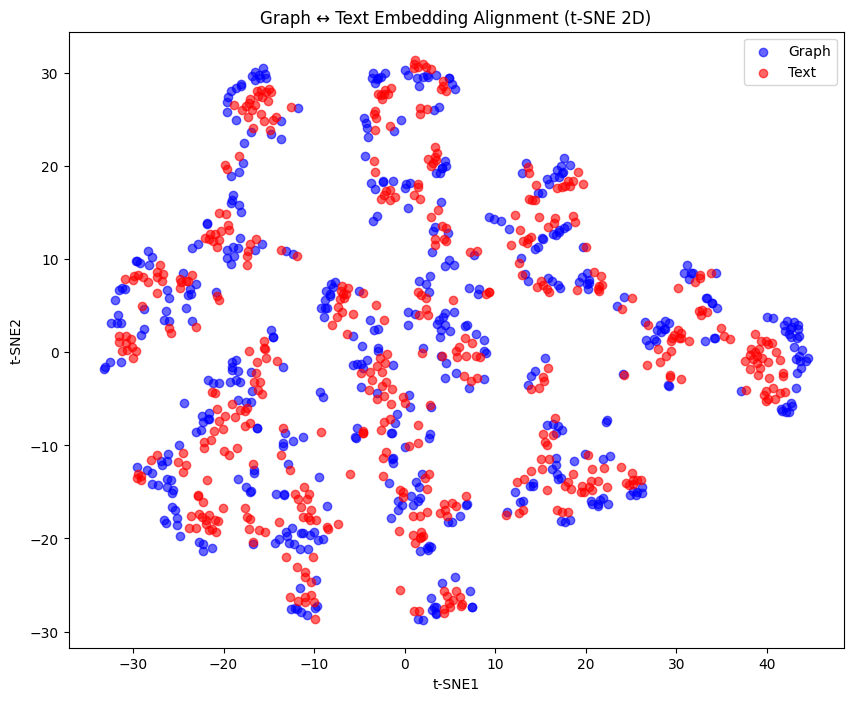

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(graph_2d[:,0], graph_2d[:,1], c='blue', label='Graph', alpha=0.6)
plt.scatter(text_2d[:,0], text_2d[:,1], c='red', label='Text', alpha=0.6)

plt.legend()
plt.title("Graph ↔ Text Embedding Alignment (t-SNE 2D)")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.show()

Use top-1 retireval to measure success/failure

Best match: 0 with score 0.7524128556251526
Best match: 1 with score 0.7727261781692505
Best match: 173 with score 0.79339998960495
Best match: 4 with score 0.7796870470046997
Best match: 4 with score 0.7740237712860107
Best match: 5 with score 0.7632139921188354
Best match: 6 with score 0.6913246512413025
Best match: 7 with score 0.791780948638916
Best match: 83 with score 0.7498558759689331
Best match: 9 with score 0.7807030081748962
Best match: 10 with score 0.844296395778656
Best match: 11 with score 0.7539764642715454
Best match: 12 with score 0.7753772735595703
Best match: 13 with score 0.7544231414794922
Best match: 14 with score 0.8088430166244507
Best match: 15 with score 0.7034751176834106
Best match: 16 with score 0.7486335635185242
Best match: 17 with score 0.7987671494483948
Best match: 18 with score 0.728888988494873
Best match: 19 with score 0.7682920098304749
Best match: 20 with score 0.8069099187850952
Best match: 21 with score 0.7835791707038879
Best match: 22 with sc

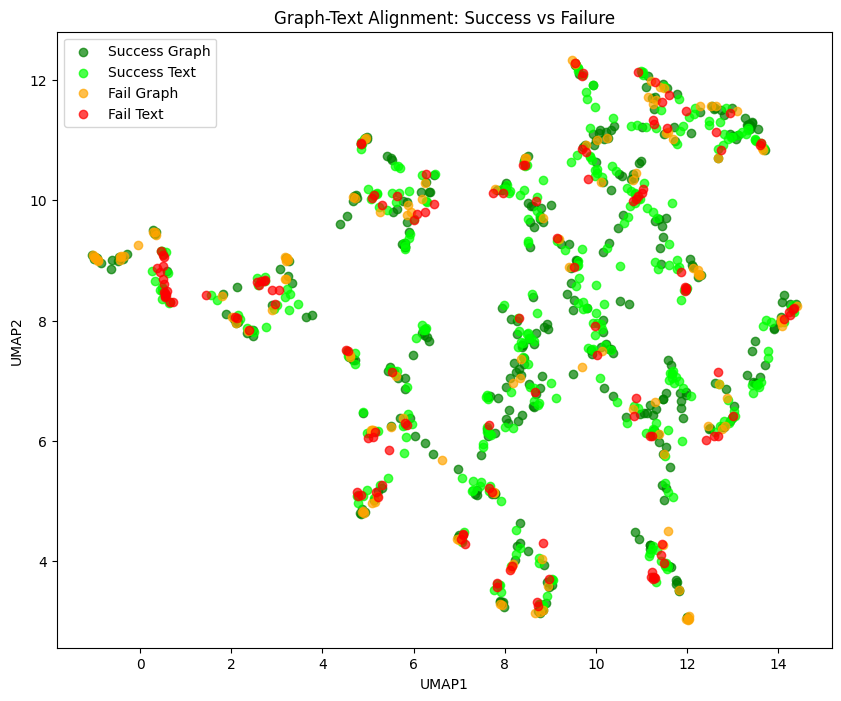

In [ ]:
success_idx = []
fail_idx = []

with torch.no_grad():
    for i in range(graph_emb.shape[0]):
        best_idx, _ = predict_best_match(
            model,
            graph_tensor[i],
            text_tensor,
            device
        )
        if best_idx == i:
            success_idx.append(i)
        else:
            fail_idx.append(i)

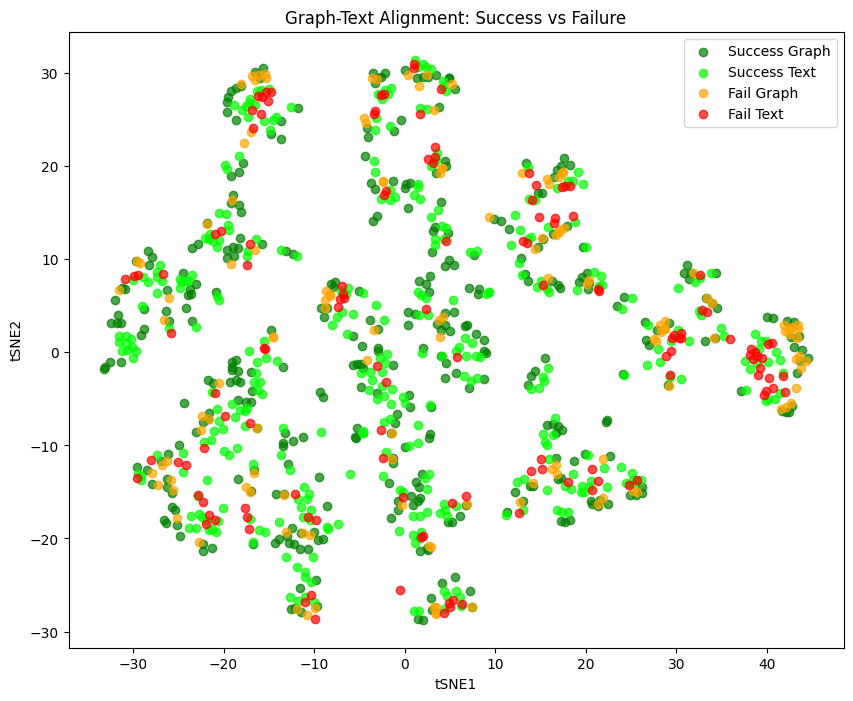

In [ ]:
plt.figure(figsize=(10,8))

# Plot successes in green
plt.scatter(graph_2d[success_idx,0], graph_2d[success_idx,1], c='green', label='Success Graph', alpha=0.7)
plt.scatter(text_2d[success_idx,0], text_2d[success_idx,1], c='lime', label='Success Text', alpha=0.7)

# Plot failures in orange
plt.scatter(graph_2d[fail_idx,0], graph_2d[fail_idx,1], c='orange', label='Fail Graph', alpha=0.7)
plt.scatter(text_2d[fail_idx,0], text_2d[fail_idx,1], c='red', label='Fail Text', alpha=0.7)

plt.legend()
plt.title("Graph-Text Alignment: Success vs Failure")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.show()

**Answer**:

<blockquote>

Using tSNE for the embeddings in the shared space, we can visualize the graph and text embeddings post-alignment.

By marking the data points differently based on whether the top-1 retrieval with graph query is the paired text embedding, we can distinguish instances where the alignment succeeded or failed.

The failures are likely due to similar embeddings of similar materials. When several materials are similar in both graph and text representations, it could result in a few similarly high retireval scores for any given graph where the highest one is not necessarily the correct text. This hypothesis can be further verified by using top-5 instead of top-1 retrieval to measure success. As shown below, the number of failures is almost negligible under top-5 success measurement, which verifies the aforementioned reason.

</blockquote>

Use top-5 retireval to measure success/failure

In [ ]:
k=5

success_idx = []
fail_idx = []

with torch.no_grad():
    for i in range(graph_emb.shape[0]):
        best_idx, sim_scores = predict_best_match(
            model,
            graph_tensor[i],
            text_tensor,
            device
        )
        topk_indices = torch.topk(sim_scores, k).indices
        if i in topk_indices:
            success_idx.append(i)
        else:
            fail_idx.append(i)

Best match: 0 with score 0.7524128556251526
Best match: 1 with score 0.7727261781692505
Best match: 173 with score 0.79339998960495
Best match: 4 with score 0.7796870470046997
Best match: 4 with score 0.7740237712860107
Best match: 5 with score 0.7632139921188354
Best match: 6 with score 0.6913246512413025
Best match: 7 with score 0.791780948638916
Best match: 83 with score 0.7498558759689331
Best match: 9 with score 0.7807030081748962
Best match: 10 with score 0.844296395778656
Best match: 11 with score 0.7539764642715454
Best match: 12 with score 0.7753772735595703
Best match: 13 with score 0.7544231414794922
Best match: 14 with score 0.8088430166244507
Best match: 15 with score 0.7034751176834106
Best match: 16 with score 0.7486335635185242
Best match: 17 with score 0.7987671494483948
Best match: 18 with score 0.728888988494873
Best match: 19 with score 0.7682920098304749
Best match: 20 with score 0.8069099187850952
Best match: 21 with score 0.7835791707038879
Best match: 22 with sc

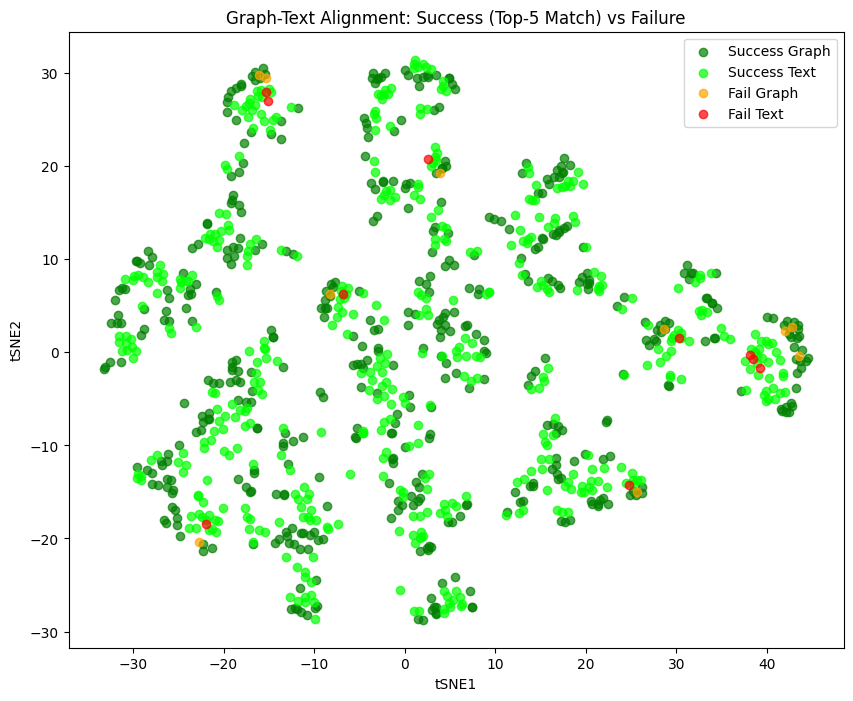

In [ ]:
plt.figure(figsize=(10,8))

# Plot successes in green
plt.scatter(graph_2d[success_idx,0], graph_2d[success_idx,1], c='green', label='Success Graph', alpha=0.7)
plt.scatter(text_2d[success_idx,0], text_2d[success_idx,1], c='lime', label='Success Text', alpha=0.7)

# Plot failures in orange
plt.scatter(graph_2d[fail_idx,0], graph_2d[fail_idx,1], c='orange', label='Fail Graph', alpha=0.7)
plt.scatter(text_2d[fail_idx,0], text_2d[fail_idx,1], c='red', label='Fail Text', alpha=0.7)

plt.legend()
plt.title("Graph-Text Alignment: Success (Top-5 Match) vs Failure")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.show()

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?

**Answer**

<blockquote>

I found the concept of contrastive learning and multimodal alignment to be particularly interesting. Though the Platonic Representation Hypothesis may not hold in realistic scenarios, the projection of same underlying concept to different modalities would naturally encourage the idea of embedding alignment in a shared latent space. This will not only enable cross-modal retrieval and tasks involving generation/design, but also enable the encoding of cross-modal information to improve model performance in conventionally unimodal tasks.

</blockquote>

2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

**Answer**

<blockquote>

I found the concepts of late fusion and gated fusion to be useful for multimodal material property prediction. Early fusion with simple concatenation has previously been the most common practice in the few multimodal works in the field, but the possibility of allowing more flexible fusion mechanisms will likely further improve prediction performances. In the preliminary exploration of this assignmet, late fusion already presented better performance than early fusion in our dataset. Digging deeper into the fusion module and exploring more sophiscated attention-based methods seem to be a promising direction within the context of our tasks.

</blockquote>

3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?